# Backtest a trading strategy on NASDAQ 100 index history (`quant-market-data`)

Loads NASDAQ 100 daily candles from the separate
[`quant-market-data`](https://github.com/) repo's Postgres database (Yahoo
Finance's `^NDX` index history, seeded there as provider `yahoo` / symbol
`NASDAQ100` in its `candles_day` table), restricts them to a chosen date
window, runs a strategy through the same backtester `04_ig_backtest_strategy.ipynb`
uses (`trading_toolkit/ig_backtest.py`), and shows the results: a metrics
table (**initial funding -> final funding**), the round-trip trade list, and
price / equity / drawdown charts.

**Data source** - unlike `01`-`04` (this repo's own SQLite pipeline of IG CFD
bid/ask candles), this notebook reads someone else's already-populated
database: the raw NASDAQ 100 **index** level (no bid/ask - Yahoo doesn't
quote one) from `quant-market-data`'s `candles_day` table, via
`trading_toolkit/market_db.py`. It doesn't touch `data/ig_market_data.db` or
download anything itself.

**Engine (`ig_backtest.py`)** - a CFD-style fixed-size position: the account
starts with `INITIAL_FUNDING` (default **20,000 AUD**), one index point is
worth `POINT_VALUE` per contract (default **1.0 AUD/point**), and `SIZE`
contracts are held, long or short. Signals are BUY / SELL / HOLD, traded the
way `ig_quant_trading` trades them live - an opposite signal closes the
position and opens the reverse one, HOLD keeps it - with fills at
the **next bar's open** after a signal (no look-ahead), a flat `fee_bps` cost
per entry and exit. Teaching-grade, not an execution simulator - applying a
CFD-style point-value/funding model to a raw index level is a simplification,
not a real product quoted on `^NDX` directly.

**Strategy** - the default is `SMAStrategy`: BUY (long) while the fast simple
moving average of the close is above the slow one, SELL (short) while it's below.
`BuyHoldStrategy` is included as the benchmark. Strategies come from
`ig_quant_trading.strategies` (imported below as `st`) - the sibling
ig-quant-trading repo that trades them live, installed here editable, so
what you backtest is exactly what it runs - every strategy it has (MACD,
Stochastic, ADX, CCI, ...) can be dropped in here. Add your own there by
subclassing `VectorizedStrategy` and implementing `signals(frame)`.

**Prerequisite:** the `trading_toolkit` package installed (`uv sync --extra
dev` from this repo's root) *and* the `quant-market-data` Postgres database
running and seeded (`docker compose up -d` in that repo, or a local Postgres
per its own README) with `PGHOST`/`PGPORT`/`PGUSER`/`PGPASSWORD`/`PGDATABASE`
set in this repo's `.env` (see `.env.sample`).

## 1. Config, window & strategy

`PROVIDER` / `SYMBOL` pick the instrument out of `quant-market-data`'s
`instruments` table (its own seed data currently only has Yahoo's NASDAQ 100,
S&P 500, Dow, ASX 200, Nikkei 225 and DAX 40 - see its `seed/manifest.py`);
`RESOLUTION` picks the `candles_<resolution>` table. Set `START` / `END` to
bound the backtest (either may be `None`), and pick the strategy + its
parameters here.

In [1]:
import pandas as pd

from ig_quant_trading import strategies as st

from trading_toolkit import ig_backtest as backtest
from trading_toolkit import market_db
from trading_toolkit.constants.ig_ohlc_fields import OHLCField

# quant-market-data instrument to backtest (provider/symbol - see its
# `instruments` table). RESOLUTION picks the candles_<resolution> table.
PROVIDER = "yahoo"
SYMBOL = "NASDAQ100"
RESOLUTION = "DAY"

# Backtest window (inclusive). None = use all available history on that side.
START = "2015-01-01"
END = None

# Strategy under test.
strategy = st.SMAStrategy(fast_period=10, slow_period=30)

# Account model.
INITIAL_FUNDING = 20_000.0  # starting balance, account currency
POINT_VALUE = 1.0           # account-currency P&L per index point, per contract
SIZE = 1.0                  # contracts held, long or short
CURRENCY = "AUD"
FEE_BPS = 1.0                # cost per entry and per exit, basis points of notional

print(f"{PROVIDER}/{SYMBOL}  {RESOLUTION}")
print(f"window  : {START or 'earliest'}  ->  {END or 'latest'}")
print(f"strategy: {strategy.label}")
print(f"account : {INITIAL_FUNDING:,.0f} {CURRENCY}   {SIZE:g} contract(s) @ {POINT_VALUE:g} {CURRENCY}/point   fee {FEE_BPS} bps")

yahoo/NASDAQ100  DAY
window  : 2015-01-01  ->  latest
strategy: SMA 10/30
account : 20,000 AUD   1 contract(s) @ 1 AUD/point   fee 1.0 bps


## 2. Load candles from `quant-market-data`

`market_db.load_candles` yields one flat OHLC dict per candle (the
instrument's own close/last price - no bid/ask to average into a mid); here
they become a `DatetimeIndex`ed DataFrame clipped to the window.

In [2]:
conn = market_db.connect()
df = pd.DataFrame(market_db.load_candles(conn, PROVIDER, SYMBOL, RESOLUTION))
conn.close()

assert not df.empty, (
    f"No candles for {PROVIDER}/{SYMBOL} / {RESOLUTION} in quant-market-data - "
    "check its Postgres DB is running and seeded (docker compose up -d there)."
)

df[OHLCField.SNAPSHOT_TIME_UTC] = pd.to_datetime(df[OHLCField.SNAPSHOT_TIME_UTC])
df = df.set_index(OHLCField.SNAPSHOT_TIME_UTC).sort_index()
df = df[[OHLCField.OPEN, OHLCField.HIGH, OHLCField.LOW, OHLCField.CLOSE, OHLCField.VOLUME]]

if START:
    df = df[df.index >= pd.Timestamp(START)]
if END:
    df = df[df.index <= pd.Timestamp(END)]

assert len(df) > 50, (
    f"Only {len(df)} bars in the window - widen START/END."
)
print(f"{len(df)} bars   {df.index[0]:%Y-%m-%d}  ->  {df.index[-1]:%Y-%m-%d}")
df.head()

2945 bars   2015-01-02  ->  2026-09-18


,open,high,low,close,volume
snapshot_time_utc,,,,,
2015-01-02,4258.600098,4276.709961,4206.459961,4230.240234,1435150000
2015-01-05,4206.549805,4210.959961,4151.850098,4160.959961,1794470000
2015-01-06,4174.779785,4176.259766,4090.330078,4110.830078,2167320000
2015-01-07,4139.850098,4169.970215,4126.390137,4160.000000,1957950000
2015-01-08,4195.490234,4247.930176,4192.629883,4240.549805,2105450000


## 3. Run the backtest

`run_backtest` returns a `BacktestResult` (equity curve, trades, stats).
`.summary()` prints the headline metrics; buy & hold over the same window is
shown for comparison.

In [3]:
result = backtest.run_backtest(
    df, strategy,
    initial_funding=INITIAL_FUNDING, point_value=POINT_VALUE, size=SIZE,
    fee_bps=FEE_BPS, currency=CURRENCY,
)
print(result.summary())

strategy           : SMA 10/30
period             : 2015-01-02 -> 2026-09-18  (2945 bars)
initial funding    : 20,000.00 AUD
final funding      : 32,003.78 AUD
profit / loss      : +12,003.78 AUD  (+60.02%)
buy & hold         : +25,413.93 AUD  (+127.07%)
position size      : 1 @ 1 AUD/point   (~0.21x funding at entry)
CAGR               : +4.10%
ann. volatility    : 11.61%
Sharpe (rf=0)      : 0.40
max drawdown       : -16.42%
time in market     : 99.0%  (long 67.1%, short 31.9%)
trades             : 94  (47 long, 47 short)
win rate           : 39.4%
avg / best / worst : +130.08 / +4,670.80 / -1,076.40 AUD


## 4. Trades

One row per round-trip (entry -> exit). `direction` is BUY (long) or SELL
(short); `points` is the price move in the trade's favour,
`pnl` is that move in `CURRENCY` (`points * POINT_VALUE * SIZE`), `open =
True` marks a position still held at the end of the window, marked out at the
last close for accounting.

In [4]:
trades = result.trades.copy()
if not trades.empty:
    trades["return_pct"] = trades["return_pct"].round(2)
trades

,direction,entry_time,exit_time,entry_price,exit_price,points,pnl,return_pct,bars_held,open
0,BUY,2015-02-17,2015-03-19,4379.32,4424.79,45.47,45.47,1.04,22,False
1,SELL,2015-03-19,2015-04-17,4424.79,4379.63,45.16,45.16,1.02,20,False
2,BUY,2015-04-17,2015-06-16,4379.63,4428.30,48.67,48.67,1.11,41,False
3,SELL,2015-06-16,2015-06-25,4428.30,4540.40,-112.10,-112.10,-2.53,7,False
4,BUY,2015-06-25,2015-06-26,4540.40,4514.37,-26.03,-26.03,-0.57,1,False
...,...,...,...,...,...,...,...,...,...,...
89,SELL,2026-06-22,2026-06-23,30529.99,29369.25,1160.74,1160.74,3.80,1,False
90,BUY,2026-06-23,2026-07-02,29369.25,29778.70,409.45,409.45,1.39,7,False
91,SELL,2026-07-02,2026-08-13,29778.70,29784.06,-5.36,-5.36,-0.02,29,False
92,BUY,2026-08-13,2026-09-14,29784.06,28890.93,-893.13,-893.13,-3.00,21,False


## 5. Charts

Price with the moving averages and buy/sell markers, the strategy equity
curve against buy & hold, and the strategy drawdown.

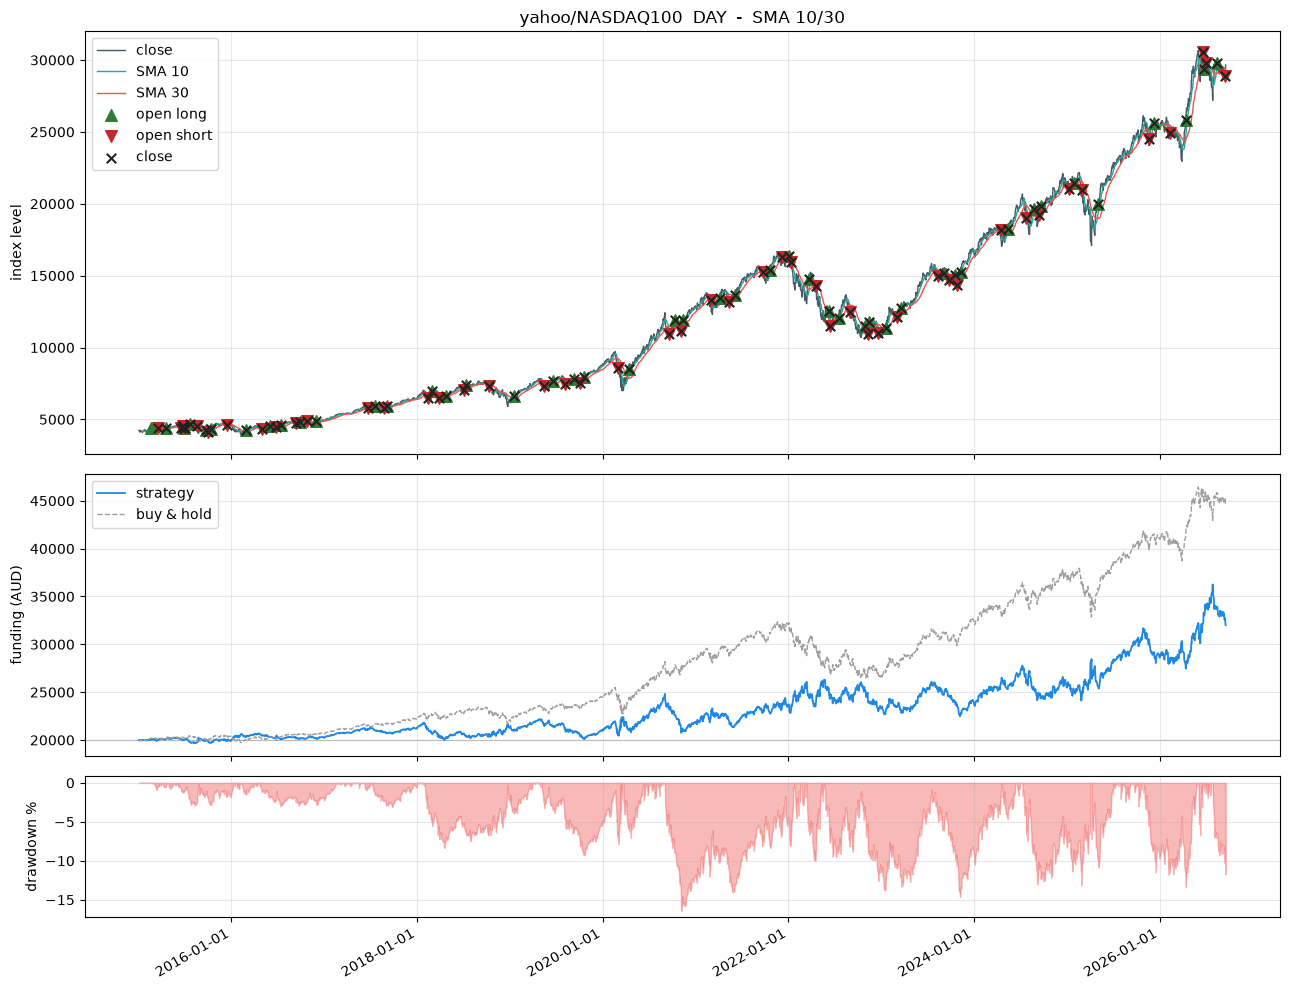

In [5]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

close = df[OHLCField.CLOSE]
eq = result.equity
# buy & hold account value: same funding, same SIZE contracts held throughout
bh = INITIAL_FUNDING + (close - close.iloc[0]) * POINT_VALUE * SIZE
dd = (eq / eq.cummax() - 1) * 100
t = result.trades

fig, (ax_px, ax_eq, ax_dd) = plt.subplots(
    3, 1, sharex=True, figsize=(13, 10),
    gridspec_kw={"height_ratios": [3, 2, 1]},
)

ax_px.plot(close.index, close, color="#455a64", lw=1, label="close")
if hasattr(strategy, "fast_period"):
    ax_px.plot(close.index, close.rolling(strategy.fast_period).mean(), color="#26a69a", lw=1,
               label=f"SMA {strategy.fast_period}")
    ax_px.plot(close.index, close.rolling(strategy.slow_period).mean(), color="#ef5350", lw=1,
               label=f"SMA {strategy.slow_period}")
if not t.empty:
    for side, marker, colour, label in (("BUY", "^", "#2e7d32", "open long"),
                                        ("SELL", "v", "#c62828", "open short")):
        e = t[t["direction"] == side]
        ax_px.scatter(e["entry_time"], e["entry_price"], marker=marker, s=70, color=colour,
                      zorder=5, label=label)
    closed = t[~t["open"]]
    ax_px.scatter(closed["exit_time"], closed["exit_price"], marker="x", s=46, color="#212121",
                  zorder=6, label="close")
ax_px.set_ylabel("index level")
ax_px.set_title(f"{PROVIDER}/{SYMBOL}  {RESOLUTION}  -  {strategy.label}")
ax_px.legend(loc="upper left")
ax_px.grid(alpha=0.3)

ax_eq.axhline(INITIAL_FUNDING, color="#bbbbbb", lw=0.8)
ax_eq.plot(eq.index, eq, color="#1e88e5", lw=1.3, label="strategy")
ax_eq.plot(bh.index, bh, color="#9e9e9e", lw=1, ls="--", label="buy & hold")
ax_eq.set_ylabel(f"funding ({CURRENCY})")
ax_eq.legend(loc="upper left")
ax_eq.grid(alpha=0.3)

ax_dd.fill_between(dd.index, dd, 0, color="#ef5350", alpha=0.4)
ax_dd.set_ylabel("drawdown %")
ax_dd.grid(alpha=0.3)

ax_dd.xaxis.set_major_locator(mdates.AutoDateLocator())
ax_dd.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 6. Compare a few strategies

Same window, same costs - a quick sweep so the numbers above have something
to sit against. Edit the list to taste.

In [6]:
candidates = [
    st.BuyHoldStrategy(),
    st.SMAStrategy(5, 20),
    st.SMAStrategy(10, 30),
    st.SMAStrategy(20, 50),
    st.SMAStrategy(50, 100),
]

rows = []
for strat in candidates:
    try:
        s = backtest.run_backtest(
            df, strat,
            initial_funding=INITIAL_FUNDING, point_value=POINT_VALUE, size=SIZE,
            fee_bps=FEE_BPS, currency=CURRENCY,
        ).stats
    except ValueError as exc:  # e.g. slow window longer than the data
        print(f"skip {strat.label}: {exc}")
        continue
    rows.append({
        "strategy": strat.label,
        f"final_funding_{CURRENCY}": round(s["final_funding"], 2),
        f"profit_{CURRENCY}": round(s["profit"], 2),
        "return_%": round(s["total_return_pct"], 2),
        "max_dd_%": round(s["max_drawdown_pct"], 2),
        "sharpe": round(s["sharpe"], 2),
        "exposure_%": round(s["exposure_pct"], 1),
        "trades": s["n_trades"],
    })

pd.DataFrame(rows).set_index("strategy")

,final_funding_AUD,profit_AUD,return_%,max_dd_%,sharpe,exposure_%,trades
strategy,,,,,,,
buy & hold,45437.20,25437.20,127.19,-18.21,0.79,100.0,1
SMA 5/20,28776.82,8776.82,43.88,-21.48,0.33,99.3,169
SMA 10/30,32003.78,12003.78,60.02,-16.42,0.40,99.0,94
SMA 20/50,21724.52,1724.52,8.62,-29.67,0.12,98.3,61
SMA 50/100,28820.49,8820.49,44.10,-20.52,0.34,96.6,24
